# The simplest quadcoil example
This is the simplest QUADCOIL + Simsopt example that loads in a `wout` file, performs the virtual casing computations, and solves the NESCOIL problem
1 minor radius away from the plasma surface.

In [1]:
from quadcoil import quadcoil
from simsopt.mhd import Vmec
from simsopt.mhd.virtual_casing import VirtualCasing
import numpy as np

In [2]:
wout_path = 'wout_LandremanPaul2021_QA_lowres.nc'
# Loading equilibrium
equil_qs = Vmec(wout_path, keep_all_files=True)
plasma_surface = equil_qs.boundary
net_poloidal_current_amperes = equil_qs.external_current()
# Slightly reduce plasma quadrature resolution
# to fit onto an 8GB card
plasma_quadpoints_phi = np.linspace(0, 1/plasma_surface.nfp, 32, endpoint=False)
plasma_quadpoints_theta = np.linspace(0, 1, 32, endpoint=False)
# Virtual casing calculation
vc = VirtualCasing.from_vmec(
    wout_path,
    src_nphi=80,
    trgt_nphi=len(plasma_quadpoints_phi), 
    trgt_ntheta=len(plasma_quadpoints_theta),
    use_stellsym=False
)
Bnormal_plasma = vc.B_external_normal

In [3]:
# Running QUADCOIL with topology constraint 
print('Running quadcoil, with auto-generated '\
      'winding surface and K_theta constraint.')
out_dict, qp, dofs, status = quadcoil(
    nfp=plasma_surface.nfp,
    stellsym=plasma_surface.stellsym,
    mpol=4,
    ntor=4,
    plasma_dofs=plasma_surface.get_dofs(),
    plasma_mpol=plasma_surface.mpol,
    plasma_ntor=plasma_surface.ntor,
    net_poloidal_current_amperes=net_poloidal_current_amperes,
    net_toroidal_current_amperes=0.,
    plasma_coil_distance=plasma_surface.minor_radius(),
    # Set the objective to 
    # f_B
    objective_name='f_B',
    # Set the constraint to K_theta
    constraint_name=('K_theta',),
    constraint_type=('>=',),
    constraint_value=np.array([0.,]),
    constraint_unit=(None,),
    # Set the output metrics to f_B and f_K
    metric_name=('f_B', 'f_K'),
)

Running quadcoil, with auto-generated winding surface and K_theta constraint.


Text(0, 0.5, 'Toroidal angle $\\phi$')

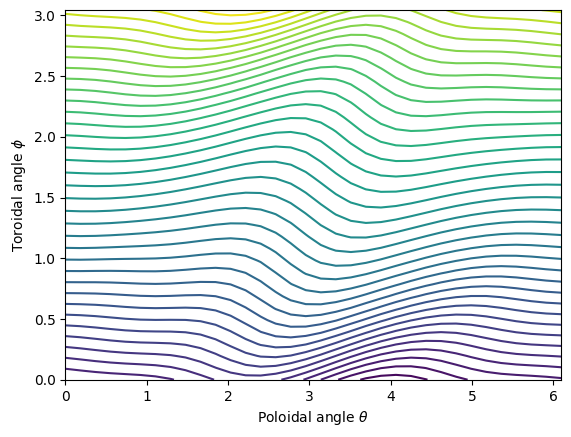

In [4]:
# Plotting the solution
from quadcoil.quantity import Phi_with_net_current
import matplotlib.pyplot as plt
import numpy as np

plt.contour(
    np.pi*2*qp.eval_surface.quadpoints_theta,
    np.pi*2*qp.eval_surface.quadpoints_phi, 
    Phi_with_net_current(qp, dofs), 
    levels=40
)
plt.xlabel(r'Poloidal angle $\theta$')
plt.ylabel(r'Toroidal angle $\phi$')

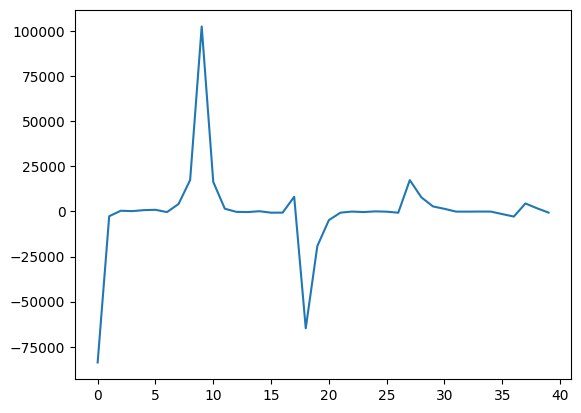

In [5]:
import jax.numpy as jnp

plt.plot(dofs['phi'])

In [21]:
# Calculating singular vectors of fB
from quadcoil.quantity import Bnormal, K
import lineax as lx

In [23]:
Bnormal_f = lambda x, qp=qp: Bnormal(qp, {'phi': x})
K_f = lambda x, qp=qp: K(qp, {'phi': x}).flatten()
Bnormal_op = lx.FunctionLinearOperator(
    fn=Bnormal_f, 
    input_structure=dofs['phi']
).as_matrix()
K_op = lx.FunctionLinearOperator(
    fn=K_f, 
    input_structure=dofs['phi']
).as_matrix()

In [31]:
Bnormal_U, Bnormal_s, Bnormal_Vh = jnp.linalg.svd(Bnormal_op, full_matrices=False)
K_U, K_s, K_Vh = jnp.linalg.svd(K_op, full_matrices=False)

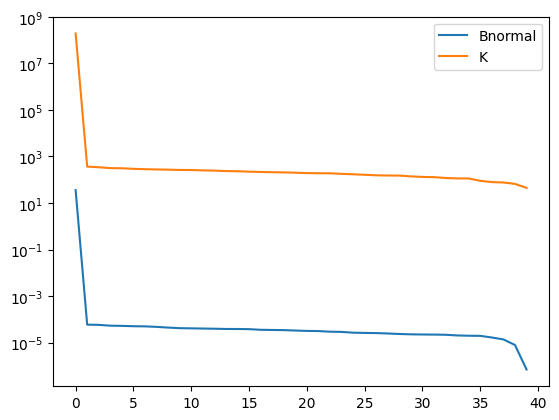

In [33]:
plt.plot(Bnormal_s, label='Bnormal')
plt.plot(K_s, label='K')
plt.yscale('log')
plt.legend()

In [ ]:
precond_lam = Bnormal_Vh@

Text(0.5, 1.0, 'phi')

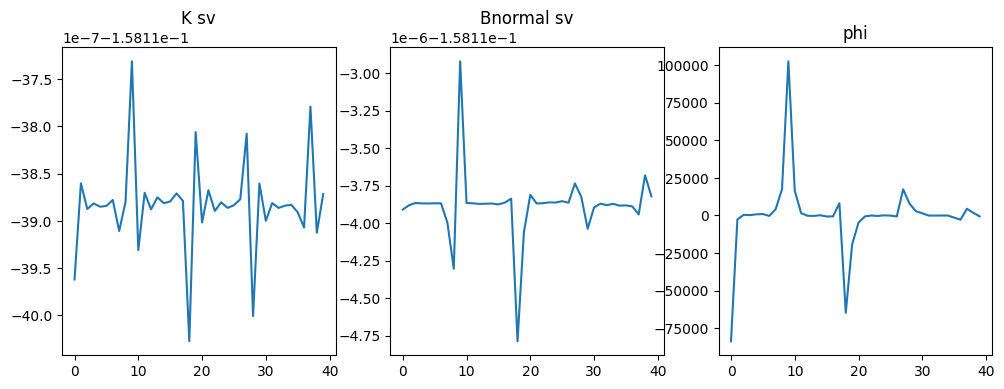

In [41]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(K_Vh[0, :])
plt.title('K sv')
plt.subplot(1,3,2)
plt.plot(Bnormal_Vh[0, :])
plt.title('Bnormal sv')
plt.subplot(1,3,3)
plt.plot(dofs['phi'])
plt.title('phi')

In [10]:
ess_alpha = 1.
ess_alpha = jnp.abs(ess_alpha)
ess_factor = jnp.exp(
    -ess_alpha 
    * jnp.linalg.norm(jnp.array(qp.make_mn()), ord=1, axis=0)
)
ess_factor = ess_factor

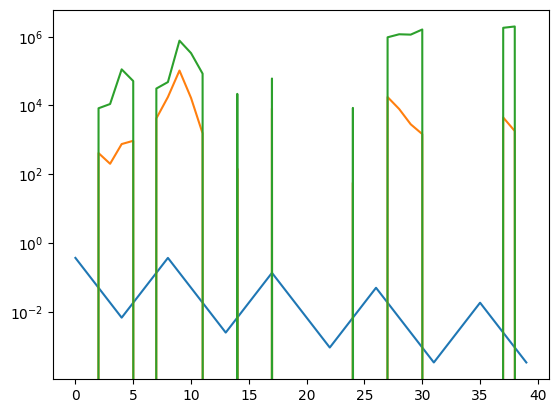

In [11]:
plt.plot(ess_factor)
plt.plot(dofs['phi'])
plt.plot(dofs['phi']/ess_factor)
plt.yscale('log')